In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("INFO")

[2025年03月31日 12时10分38秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

R[write to console]: 错误: ignoring SIGPIPE signal



## 数据

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad")
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"

sc.pp.subsample(fadata, n_obs=500)

fadata

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
import pandas as pd

# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
        ],
    columns=["from", "to"]
)

fadata.add_trajectory_mannually(milestone_network)

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color', 'milestone'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'milestone_colors', 'milestone_color_colors', 'milestone_color_dict'
    obsm: 'X_pca', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced', 'expression', 'count'

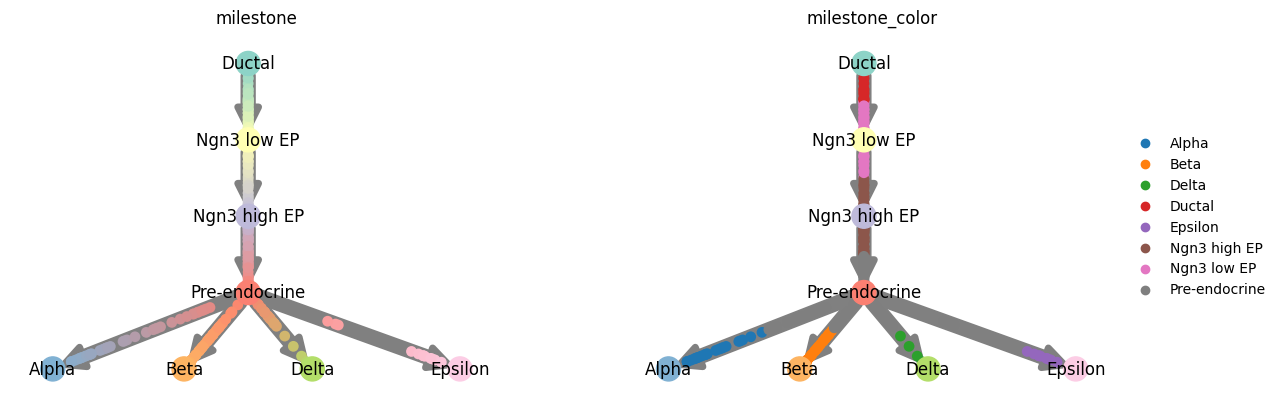

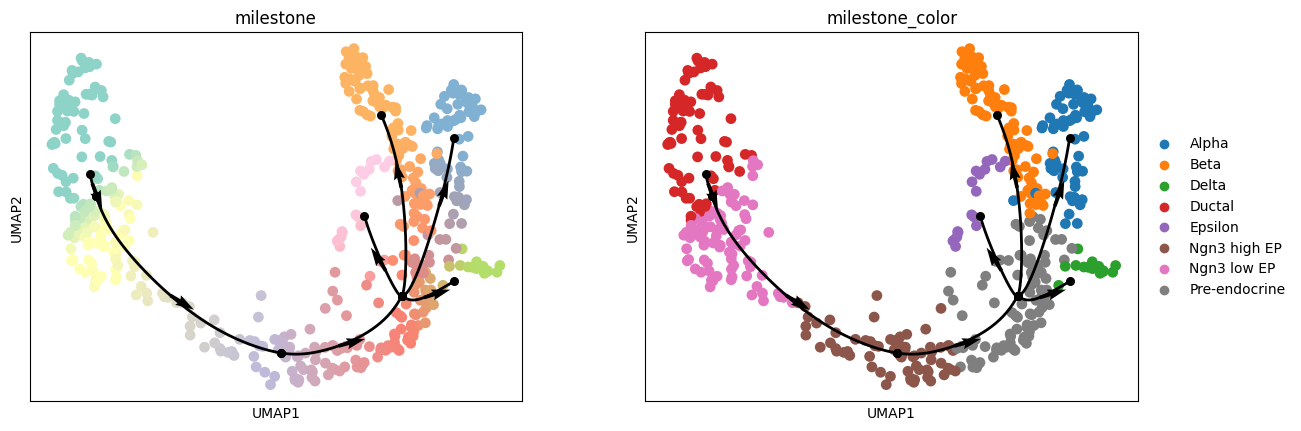

In [4]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)
fadata

Method and plot

[2025年03月31日 12时10分43秒] INFO     Loaded function: <function cf_paga at 0x714b3a387400> from                  
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_paga.py                                                               
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x714b50f71f90>                                                                   
Normalized count data: X, spliced, unspliced.
Logarithmized X.
[2025年03月31日 12时10分48秒] INFO     Loaded function: <function cf_comp1 at 0x714b30dc5120> from                 
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_comp1.py                                                              
                     

  0%|          | 0/500 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:00) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


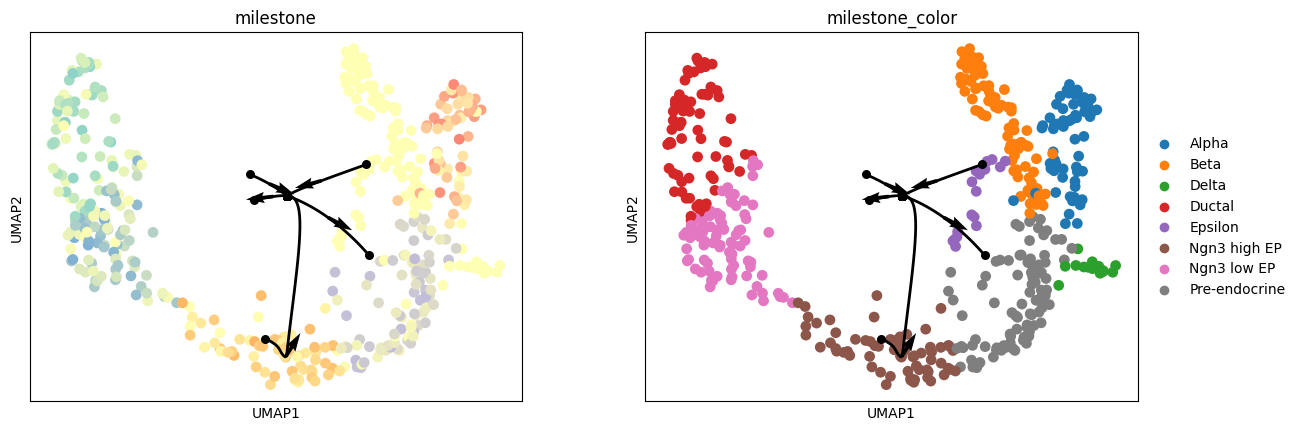

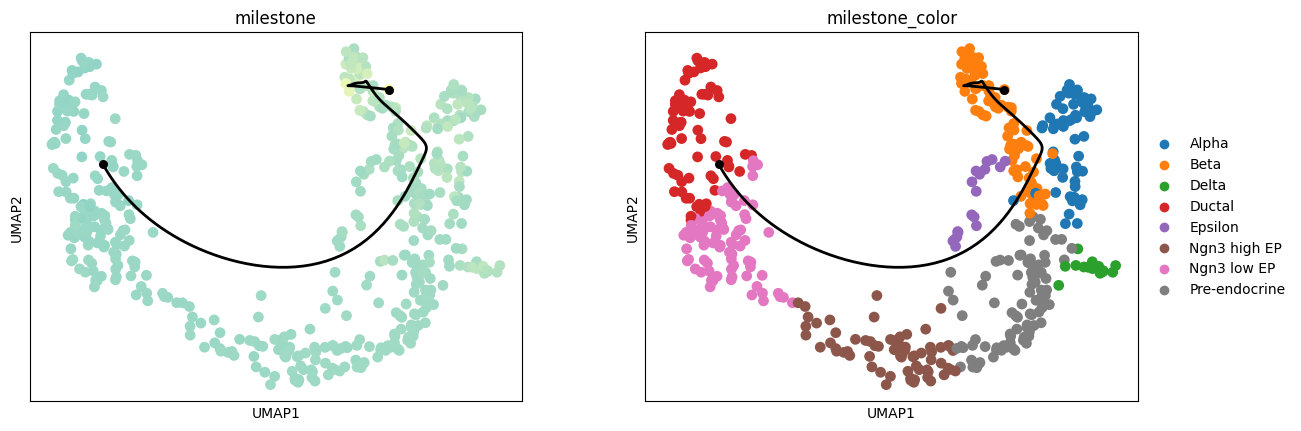

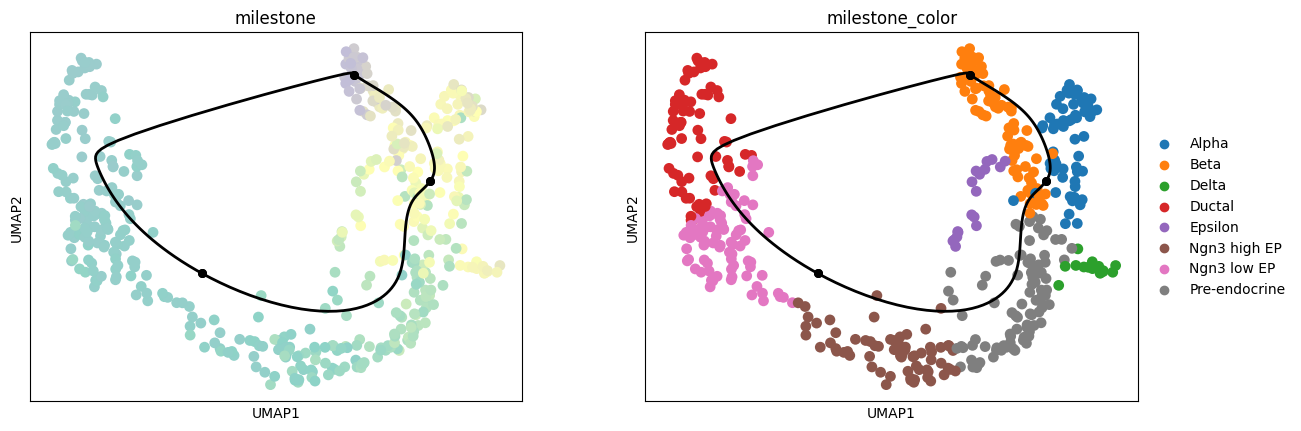

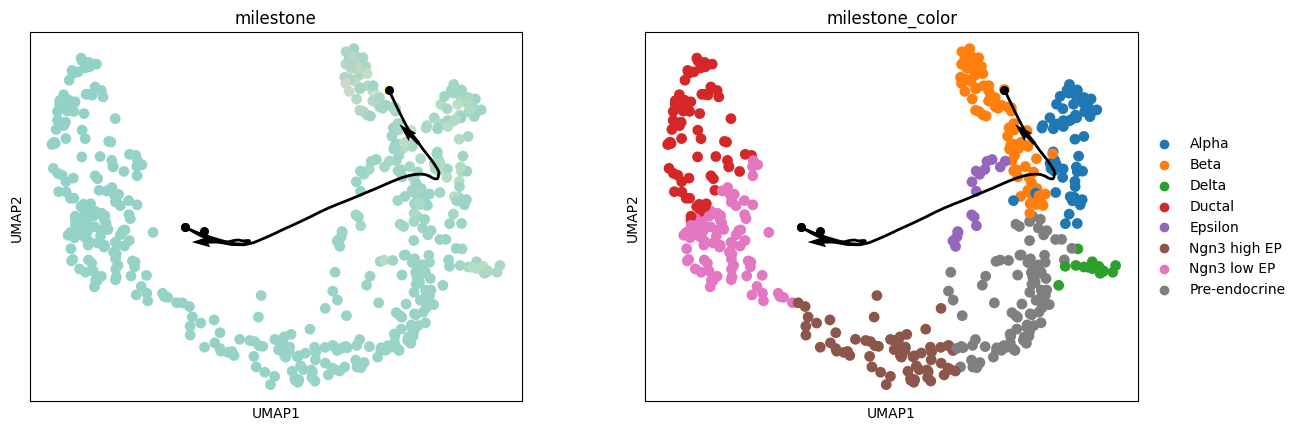

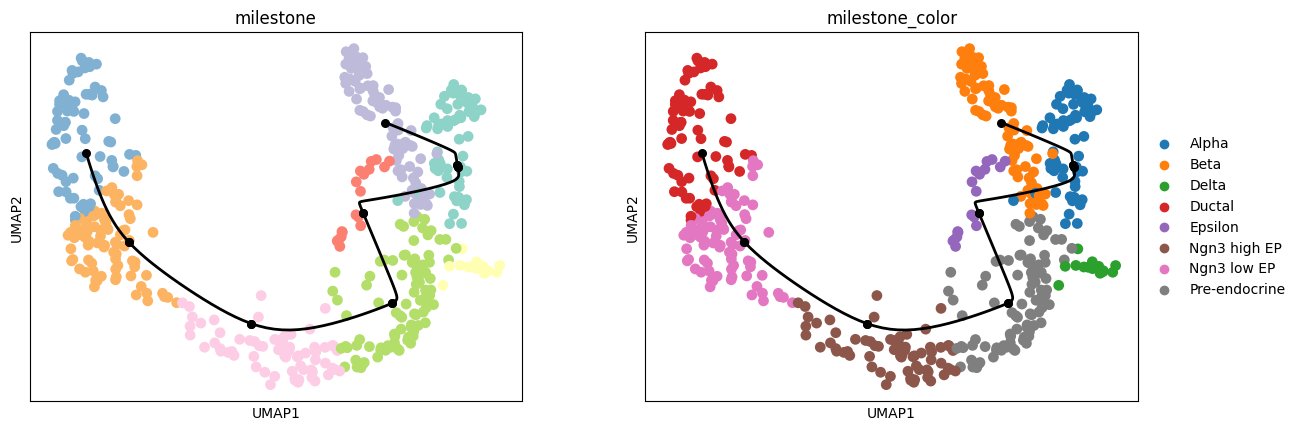

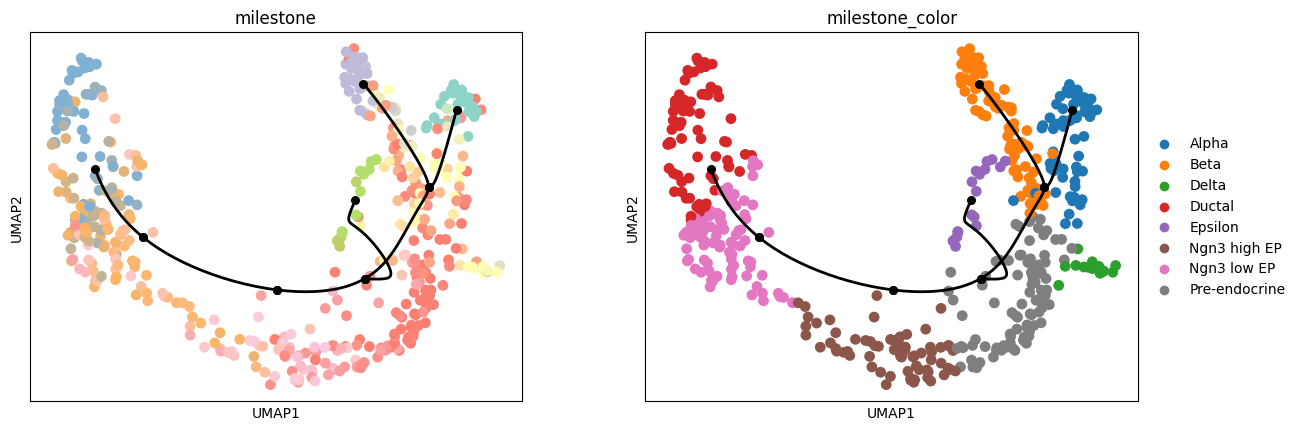

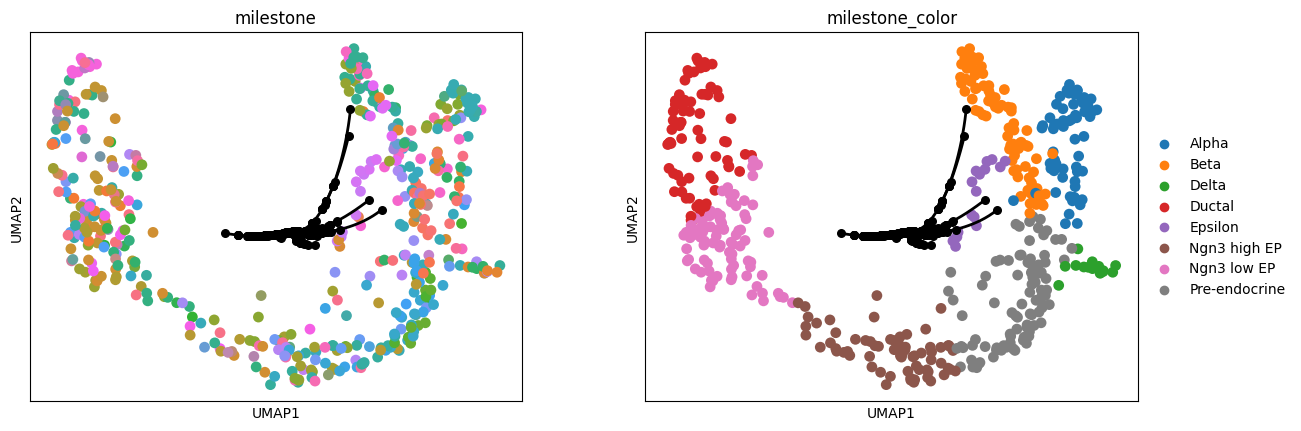

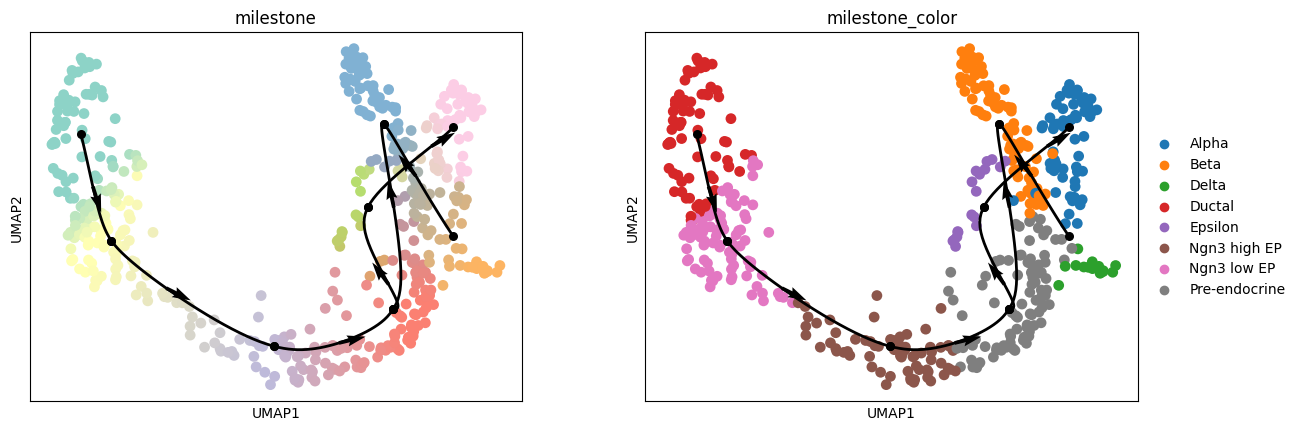

In [5]:
# TODO: PAGA need to be optimized, disconnected graph
prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata


method_name_list = ["paga", "comp1", "angle", "state_comp", "cluster_mst", "projection_mst", "graph_mst", "scvelo"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)

    method.infer_trajectory(fadata)

    cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)

## 指标

In [6]:
parsed_model_name_list = fadata.get_all_model_name() # 解析后的模型名称
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list

[2025年03月31日 12时11分16秒] WARNING  'ref' is not a valid random_time_string, don't need parse                   


(['ref',
  'paga-python_function',
  'comp1-python_function',
  'angle-python_function',
  'state_comp-python_function',
  'cluster_mst-python_function',
  'projection_mst-python_function',
  'graph_mst-python_function',
  'scvelo-python_function'],
 ['ref',
  '20250331_121043__paga-python_function__PPqiXtv1Dm',
  '20250331_121048__comp1-python_function__b8EkjN6lHk',
  '20250331_121050__angle-python_function__VSTYQLWLFp',
  '20250331_121051__state_comp-python_function__J7f9EcVjPi',
  '20250331_121052__cluster_mst-python_function__Gaq0o4gXl2',
  '20250331_121054__projection_mst-python_function__J2DjJ3gr9Q',
  '20250331_121055__graph_mst-python_function__dvyXs98UAq',
  '20250331_121102__scvelo-python_function__e9TGR93wMP'])

In [7]:
metrics = cfe.metric.metrics
metric_id_list = metrics[metrics["category"] == "topology"]["metric_id"].tolist()
metric_id_list

['edge_flip', 'him', 'isomorphic']

In [9]:
import pandas as pd


model_metric_dict = {}

for model_name in model_name_list:
    if "angle-python_function" not in model_name: # angle模型
        model_metric = cfe.metric.calculate_metrics(
            fadata,
            metrics=metric_id_list,
            now_model=model_name,
            ref_model="ref"
        )
        model_metric_dict[model_name] = model_metric

df = pd.DataFrame(model_metric_dict).T
df

,isomorphic,edge_flip,him
ref,1.0,1.00,0.0
20250331_121043__paga-python_function__PPqiXtv1Dm,0.0,0.00,0.0
20250331_121048__comp1-python_function__b8EkjN6lHk,0.0,0.00,0.0
20250331_121051__state_comp-python_function__J7f9EcVjPi,0.0,0.40,0.0
20250331_121052__cluster_mst-python_function__Gaq0o4gXl2,0.0,0.00,0.0
20250331_121054__projection_mst-python_function__J2DjJ3gr9Q,0.0,0.50,0.0
20250331_121055__graph_mst-python_function__dvyXs98UAq,0.0,0.00,0.0
20250331_121102__scvelo-python_function__e9TGR93wMP,0.0,0.57,0.0
